# Flag Detection — Data Pipeline
**Dataset:** Country Flags (Roboflow) — YOLOv8 format  
**Phases:** Investigation → Cleaning → Preprocessing → Augmentation → Validation

### Install Dependencies

In [1]:
!pip install roboflow opencv-python-headless matplotlib seaborn pillow tqdm pyyaml albumentations ultralytics


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Imports & Config

In [ ]:
import os
import cv2
import yaml
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
from collections import defaultdict, Counter
import random
import shutil
import albumentations as A
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATASET_ROOT = Path('Country-Flags-4')  
SPLITS       = ['train', 'valid', 'test']
SEED         = 42
random.seed(SEED)
np.random.seed(SEED)

print(' Imports OK')
print(f'Dataset root: {DATASET_ROOT.resolve()}')

 Imports OK
Dataset root: D:\Desktop\Flag Detection - Eagles\Country-Flags-4


---
## Phase 1 — Data Investigation

### 1.1  Download from Roboflow

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="2qus15L4cUeznPQWlU9f")
project = rf.workspace("phamdata").project("country-flags-2t33e")
version = project.version(4)
dataset = version.download("yolov8")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...


### 1.2  Load data.yaml & Class Names

In [4]:
DATASET_ROOT = Path('Country-Flags-4')

yaml_path = DATASET_ROOT / 'data.yaml'
with open(yaml_path) as f:
    data_cfg = yaml.safe_load(f)

class_names  = data_cfg['names']
total_classes = len(class_names)

print(f'Total classes (countries): {total_classes}')
print('\nClass names:')
for i, name in enumerate(class_names):
    print(f'  [{i:3d}] {name}')

Total classes (countries): 88

Class names:
  [  0] Afghanistan
  [  1] Albania
  [  2] Algeria Flag
  [  3] American Samoa
  [  4] Andorra Flag
  [  5] Angola Flag
  [  6] Anguilla Flag
  [  7] Antigua and Barbuda
  [  8] Argentina
  [  9] Armenia
  [ 10] Australia
  [ 11] Austria
  [ 12] Bahrain
  [ 13] Belgium
  [ 14] Bolivia
  [ 15] Bosnia and Herzegovina
  [ 16] Brazil
  [ 17] Cameroon
  [ 18] Canada
  [ 19] Cape Verde
  [ 20] Chile
  [ 21] China
  [ 22] Colombia
  [ 23] Costa Rica
  [ 24] Croatia
  [ 25] Czech Republic
  [ 26] Democratic Republic of the Congo
  [ 27] Denmark
  [ 28] Ecuador
  [ 29] Egypt
  [ 30] El Salvador
  [ 31] England
  [ 32] Finland
  [ 33] France
  [ 34] Gabon
  [ 35] Georgia
  [ 36] Germany
  [ 37] Ghana
  [ 38] Greece
  [ 39] Haiti
  [ 40] Honduras
  [ 41] Hungary
  [ 42] Iceland
  [ 43] Iran
  [ 44] Iraq
  [ 45] Israel
  [ 46] Italy
  [ 47] Ivory Coast
  [ 48] Jamaica
  [ 49] Japan
  [ 50] Jordan
  [ 51] Madagascar
  [ 52] Mali
  [ 53] Mexico
  [ 54] Mo

## 1.3  Count Images per Split

Split           Count       %
──────────────────────────────
train            8940   87.8%
valid             827    8.1%
test              420    4.1%
──────────────────────────────
TOTAL           10187


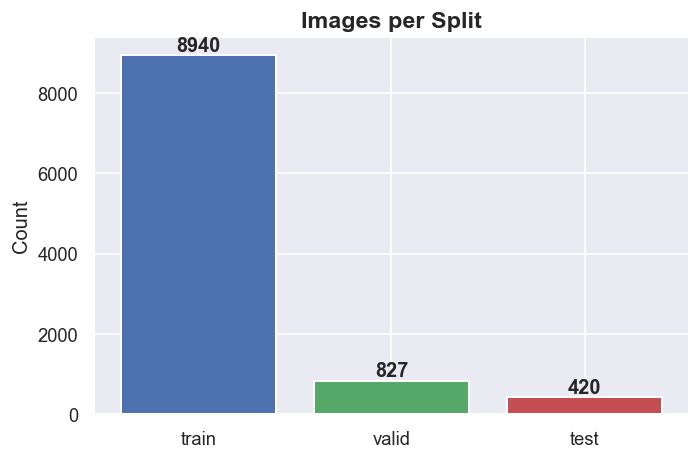

In [5]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def get_image_paths(split):
    img_dir = DATASET_ROOT / split / 'images'
    return [p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS]

split_counts = {s: len(get_image_paths(s)) for s in SPLITS}
total_images  = sum(split_counts.values())

print(f'{'Split':<12} {'Count':>8}  {'%':>6}')
print('─' * 30)
for s, c in split_counts.items():
    print(f'{s:<12} {c:>8}  {c/total_images*100:>5.1f}%')
print('─' * 30)
print(f'{'TOTAL':<12} {total_images:>8}')

# Bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(split_counts.keys(), split_counts.values(), color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, split_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Images per Split', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/split_counts.png', dpi=150)
plt.show()

## 1.4  Missing / Incomplete Classes

In [6]:
def count_class_occurrences(split):
    label_dir = DATASET_ROOT / split / 'labels'
    counts = Counter()
    for lf in label_dir.glob('*.txt'):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

all_counts = Counter()
for s in SPLITS:
    all_counts.update(count_class_occurrences(s))

represented = set(all_counts.keys())
all_ids     = set(range(total_classes))
missing     = all_ids - represented
rare        = {cid: cnt for cid, cnt in all_counts.items() if cnt < 5}

print(f'Classes with annotations : {len(represented)} / {total_classes}')
print(f'Missing classes          : {len(missing)}')
if missing:
    print('  →', [class_names[i] for i in sorted(missing)])
print(f'Rare classes (<5 samples): {len(rare)}')
if rare:
    for cid, cnt in sorted(rare.items(), key=lambda x: x[1]):
        print(f'  [{cid}] {class_names[cid]}: {cnt}')

Classes with annotations : 88 / 88
Missing classes          : 0
Rare classes (<5 samples): 0


## 1.5  Class Imbalance Analysis

Max class count  : 212  (Brazil)
Min class count  : 21  (Cape Verde)
Imbalance ratio  : 10.10x
Mean per class   : 115.9
Std              : 45.6


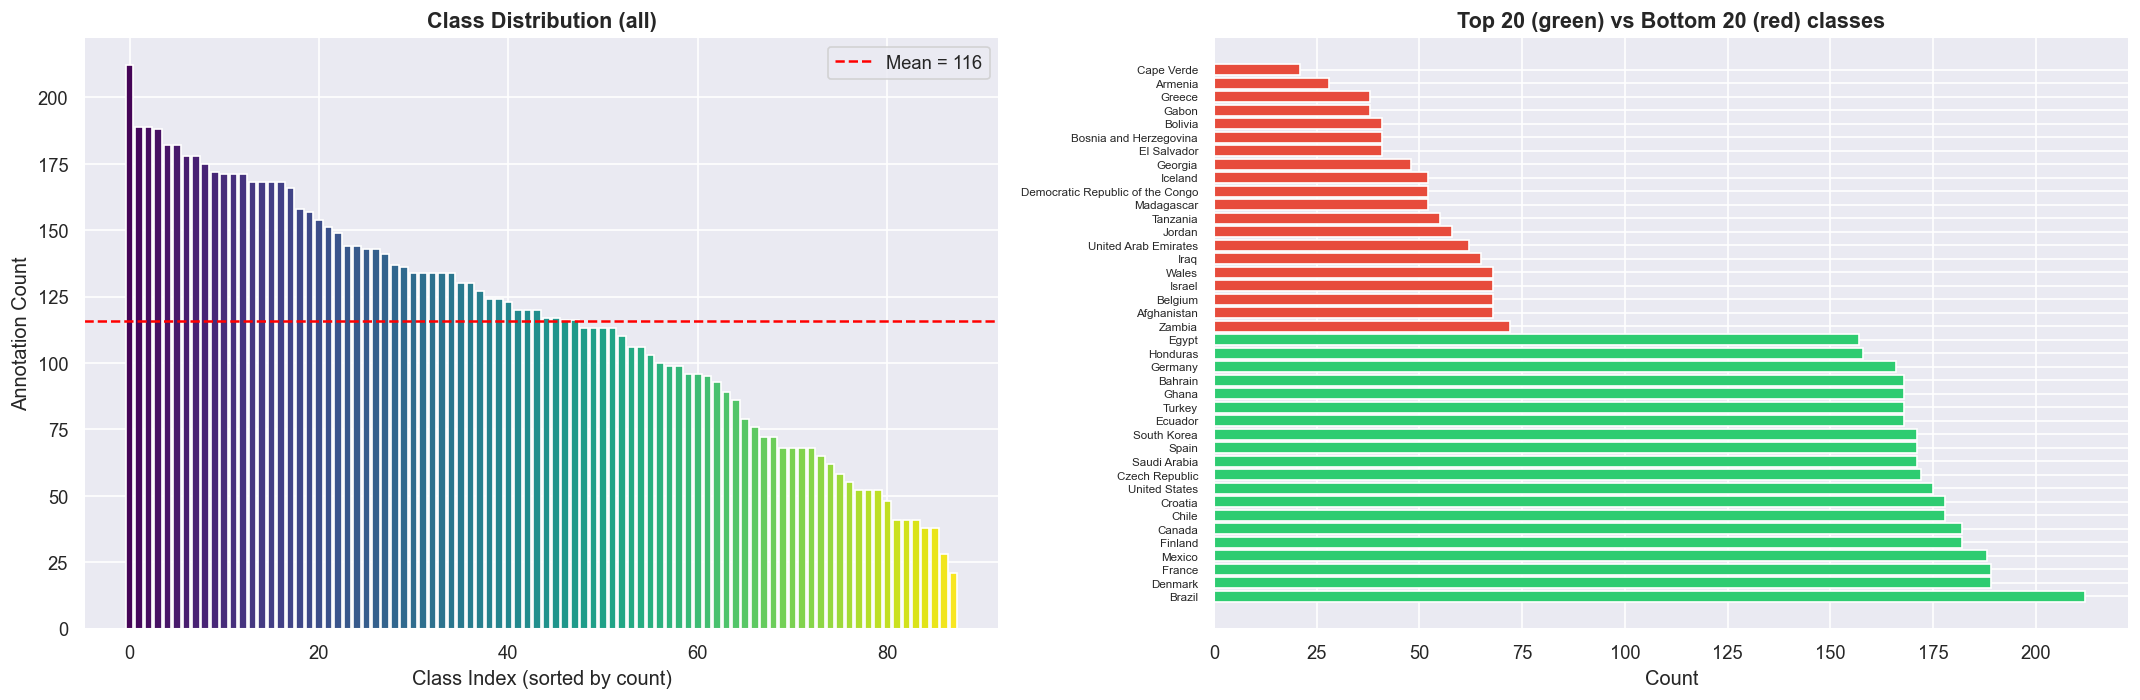

In [7]:
counts_df = pd.DataFrame([
    {'class_id': cid, 'class_name': class_names[cid], 'count': cnt}
    for cid, cnt in sorted(all_counts.items())
]).sort_values('count', ascending=False)

max_count = counts_df['count'].max()
min_count = counts_df['count'].min()
imbalance_ratio = max_count / max(min_count, 1)

print(f'Max class count  : {max_count}  ({counts_df.iloc[0]["class_name"]})')
print(f'Min class count  : {min_count}  ({counts_df.iloc[-1]["class_name"]})')
print(f'Imbalance ratio  : {imbalance_ratio:.2f}x')
print(f'Mean per class   : {counts_df["count"].mean():.1f}')
print(f'Std              : {counts_df["count"].std():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Full bar chart
ax = axes[0]
palette = sns.color_palette('viridis', len(counts_df))
ax.bar(range(len(counts_df)), counts_df['count'].values, color=palette)
ax.axhline(counts_df['count'].mean(), color='red', linestyle='--', label=f'Mean = {counts_df["count"].mean():.0f}')
ax.set_title('Class Distribution (all)', fontsize=13, fontweight='bold')
ax.set_xlabel('Class Index (sorted by count)')
ax.set_ylabel('Annotation Count')
ax.legend()

# Top & Bottom 20
ax = axes[1]
top20    = counts_df.head(20)
bottom20 = counts_df.tail(20)
combined = pd.concat([top20, bottom20])
colors_combined = ['#2ecc71']*20 + ['#e74c3c']*20
ax.barh(range(len(combined)), combined['count'].values, color=colors_combined)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['class_name'].values, fontsize=7)
ax.set_title('Top 20 (green) vs Bottom 20 (red) classes', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')

plt.tight_layout()
plt.savefig('outputs/class_distribution.png', dpi=150)
plt.show()

## 1.6  Image Resolution Analysis

Scanning test: 100%|██████████| 420/420 [00:02<00:00, 142.50it/s]


Min  resolution: 36x26
Max  resolution: 2048x1638
Mean resolution: 467x317
Most common    : (np.int64(400), np.int64(224))

→ Recommended resize target: 400x224


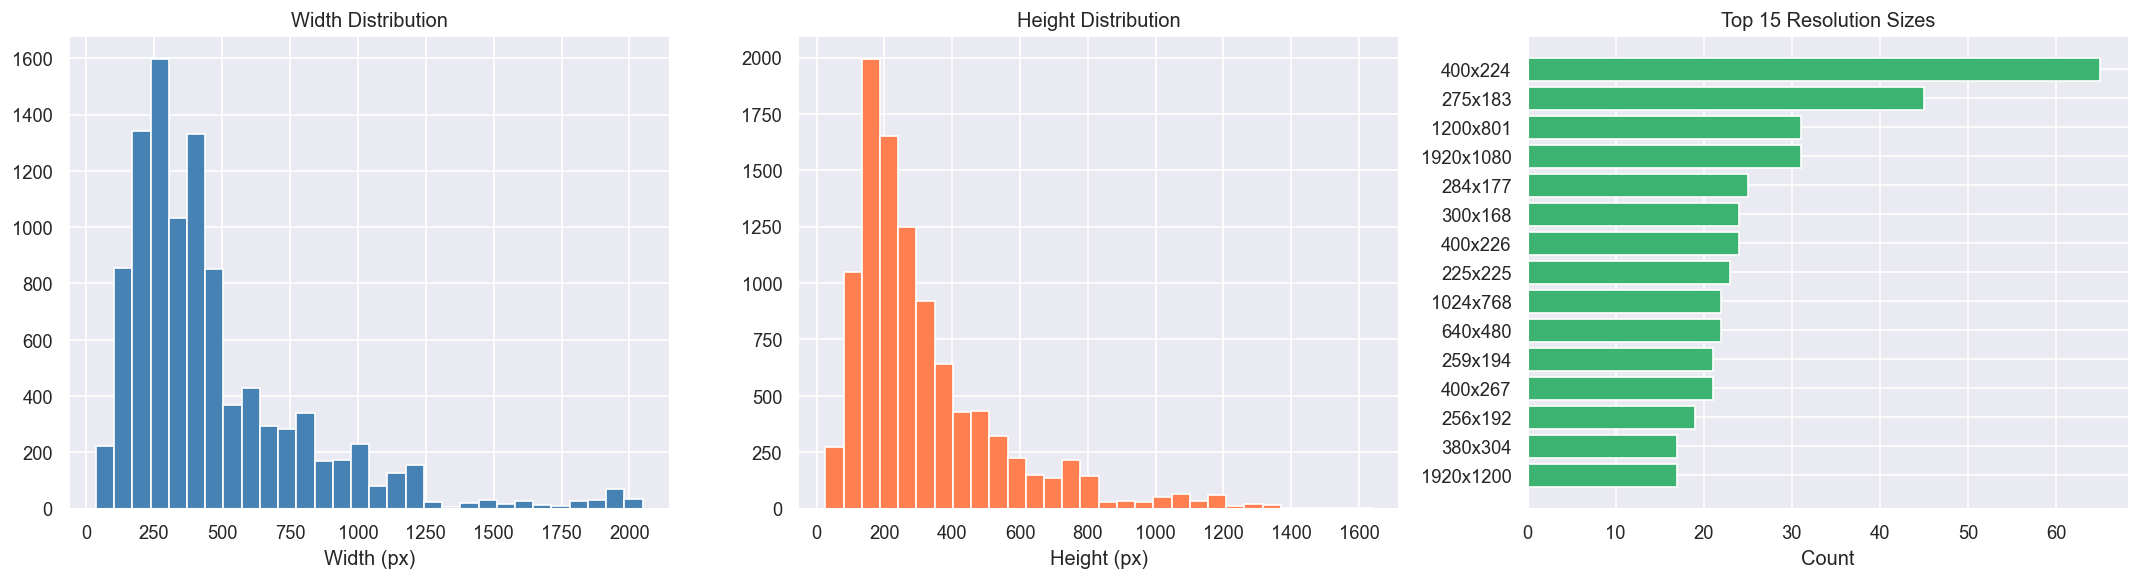

In [8]:
resolutions = []
for split in SPLITS:
    for img_path in tqdm(get_image_paths(split), desc=f'Scanning {split}'):
        try:
            with Image.open(img_path) as img:
                w, h = img.size
                resolutions.append({'split': split, 'path': str(img_path),
                                    'width': w, 'height': h, 'area': w*h})
        except Exception:
            pass

res_df = pd.DataFrame(resolutions)

print(f"Min  resolution: {res_df['width'].min()}x{res_df['height'].min()}")
print(f"Max  resolution: {res_df['width'].max()}x{res_df['height'].max()}")
print(f"Mean resolution: {res_df['width'].mean():.0f}x{res_df['height'].mean():.0f}")
print(f"Most common    : {res_df.groupby(['width','height']).size().idxmax()}")

most_common_res = res_df.groupby(['width','height']).size().idxmax()
TARGET_W, TARGET_H = most_common_res
print(f'\n→ Recommended resize target: {TARGET_W}x{TARGET_H}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(res_df['width'],  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Width Distribution');  axes[0].set_xlabel('Width (px)')

axes[1].hist(res_df['height'], bins=30, color='coral',     edgecolor='white')
axes[1].set_title('Height Distribution'); axes[1].set_xlabel('Height (px)')

size_counts = res_df.groupby(['width','height']).size().reset_index(name='count').sort_values('count', ascending=False).head(15)
size_labels = [f"{r.width}x{r.height}" for _, r in size_counts.iterrows()]
axes[2].barh(size_labels[::-1], size_counts['count'].values[::-1], color='mediumseagreen')
axes[2].set_title('Top 15 Resolution Sizes'); axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('outputs/resolution_analysis.png', dpi=150)
plt.show()

## 1.7  Bounding Box / Flag Size Analysis

BBox test: 100%|██████████| 420/420 [00:00<00:00, 7474.83it/s]


Bounding Box Statistics (normalized YOLO format):
              bw         bh   area_pct
count  10181.000  10181.000  10181.000
mean       0.998      0.998     99.641
std        0.021      0.022      3.409
min        0.382      0.486     23.743
25%        1.000      1.000    100.000
50%        1.000      1.000    100.000
75%        1.000      1.000    100.000
max        1.009      1.015    102.410

Small objects (area < 1%): 0 / 10181


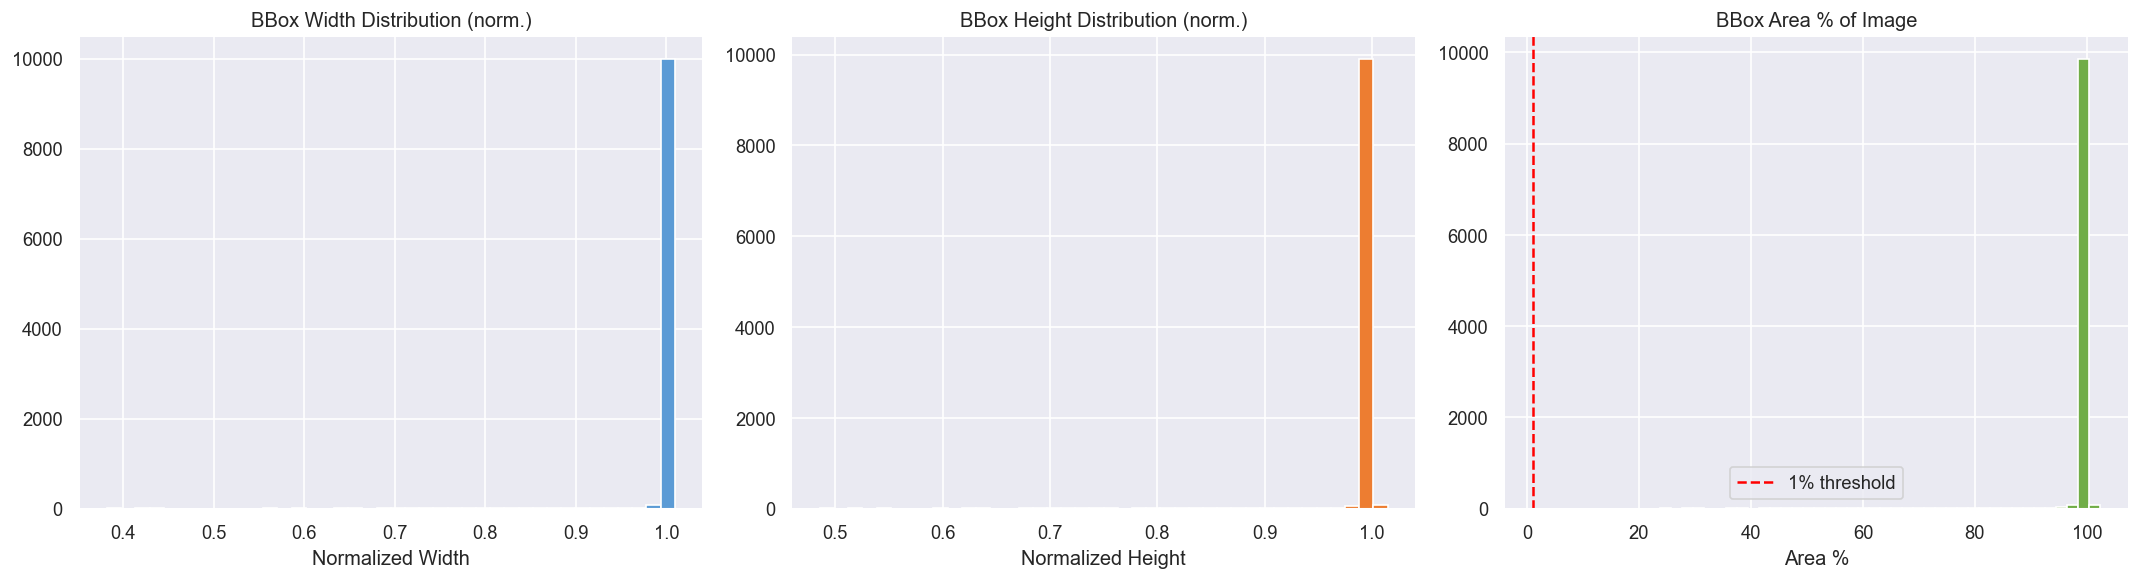

In [9]:
bbox_stats = []
for split in SPLITS:
    label_dir = DATASET_ROOT / split / 'labels'
    for lf in tqdm(list(label_dir.glob('*.txt')), desc=f'BBox {split}'):
        with open(lf) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    area_pct = bw * bh * 100
                    bbox_stats.append({'class_id': cls, 'cx': cx, 'cy': cy,
                                       'bw': bw, 'bh': bh, 'area_pct': area_pct})

bb_df = pd.DataFrame(bbox_stats)

print('Bounding Box Statistics (normalized YOLO format):')
print(bb_df[['bw','bh','area_pct']].describe().round(3))
print(f"\nSmall objects (area < 1%): {(bb_df['area_pct'] < 1).sum()} / {len(bb_df)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(bb_df['bw'],       bins=40, color='#5B9BD5', edgecolor='white')
axes[0].set_title('BBox Width Distribution (norm.)'); axes[0].set_xlabel('Normalized Width')

axes[1].hist(bb_df['bh'],       bins=40, color='#ED7D31', edgecolor='white')
axes[1].set_title('BBox Height Distribution (norm.)'); axes[1].set_xlabel('Normalized Height')

axes[2].hist(bb_df['area_pct'], bins=40, color='#70AD47', edgecolor='white')
axes[2].axvline(1, color='red', linestyle='--', label='1% threshold')
axes[2].set_title('BBox Area % of Image'); axes[2].set_xlabel('Area %')
axes[2].legend()

plt.tight_layout()
plt.savefig('outputs/bbox_analysis.png', dpi=150)
plt.show()

---
# Phase 2 — Data Cleaning

## 2.1  Remove Corrupted Images

In [10]:
corrupted = []
for split in SPLITS:
    for img_path in tqdm(get_image_paths(split), desc=f'Checking {split}'):
        try:
            img = Image.open(img_path)
            img.verify()
        except Exception as e:
            corrupted.append({'path': str(img_path), 'reason': str(e)})

print(f'Corrupted images found: {len(corrupted)}')
for item in corrupted:
    print(f"  {item['path']} — {item['reason']}")
    label_path = Path(item['path']).parent.parent / 'labels' / (Path(item['path']).stem + '.txt')
    Path(item['path']).unlink(missing_ok=True)
    label_path.unlink(missing_ok=True)

print('✅ Corrupted images removed (if any).')

Checking test: 100%|██████████| 420/420 [00:00<00:00, 7833.62it/s]

Corrupted images found: 0
✅ Corrupted images removed (if any).


## 2.2  Remove Duplicate Images

In [12]:
def file_hash(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

seen_hashes = {}
duplicates  = []

for split in SPLITS:
    for img_path in tqdm(get_image_paths(split), desc=f'Hashing {split}'):
        h = file_hash(img_path)
        if h in seen_hashes:
            duplicates.append({'dup': str(img_path), 'original': seen_hashes[h]})
        else:
            seen_hashes[h] = str(img_path)

print(f'Duplicates found: {len(duplicates)}')
for d in duplicates:
    print(f"  DUP: {d['dup']}  ←→  ORIG: {d['original']}")
    label_dup = Path(d['dup']).parent.parent / 'labels' / (Path(d['dup']).stem + '.txt')
    Path(d['dup']).unlink(missing_ok=True)
    label_dup.unlink(missing_ok=True)

print('✅ Duplicates removed (if any).')

Hashing test: 100%|██████████| 420/420 [00:00<00:00, 2021.69it/s]

Duplicates found: 0
✅ Duplicates removed (if any).


## 2.3  Fix Annotation Errors

In [13]:
annotation_issues = []
fixed_count = 0

for split in SPLITS:
    label_dir = DATASET_ROOT / split / 'labels'
    for lf in tqdm(list(label_dir.glob('*.txt')), desc=f'Checking labels {split}'):
        valid_lines = []
        with open(lf) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                annotation_issues.append({'file': str(lf), 'issue': 'wrong fields', 'line': line.strip()})
                continue
            cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            if cls < 0 or cls >= total_classes:
                annotation_issues.append({'file': str(lf), 'issue': f'invalid class {cls}', 'line': line.strip()})
                continue
            if bw <= 0 or bh <= 0:
                annotation_issues.append({'file': str(lf), 'issue': 'zero-size box', 'line': line.strip()})
                continue
            # Clip to [0,1]
            cx = max(0.0, min(1.0, cx)); cy = max(0.0, min(1.0, cy))
            bw = max(0.001, min(1.0, bw)); bh = max(0.001, min(1.0, bh))
            valid_lines.append(f'{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')
        if len(valid_lines) != len(lines):
            fixed_count += 1
            with open(lf, 'w') as f:
                f.writelines(valid_lines)

print(f'Annotation issues found : {len(annotation_issues)}')
print(f'Label files fixed       : {fixed_count}')
if annotation_issues:
    issues_df = pd.DataFrame(annotation_issues)
    print(issues_df['issue'].value_counts())

Checking labels test: 100%|██████████| 420/420 [00:00<00:00, 6078.07it/s]

Annotation issues found : 19
Label files fixed       : 19
issue
wrong fields    19
Name: count, dtype: int64


---
# Phase 3 — Image Preprocessing

## 3.1  Resize & Normalize

Processing test: 100%|██████████| 420/420 [00:06<00:00, 61.27it/s]


Processed OK  : 10187
Failed        : 0
Output root   : D:\Desktop\Flag Detection - Eagles\processed_dataset


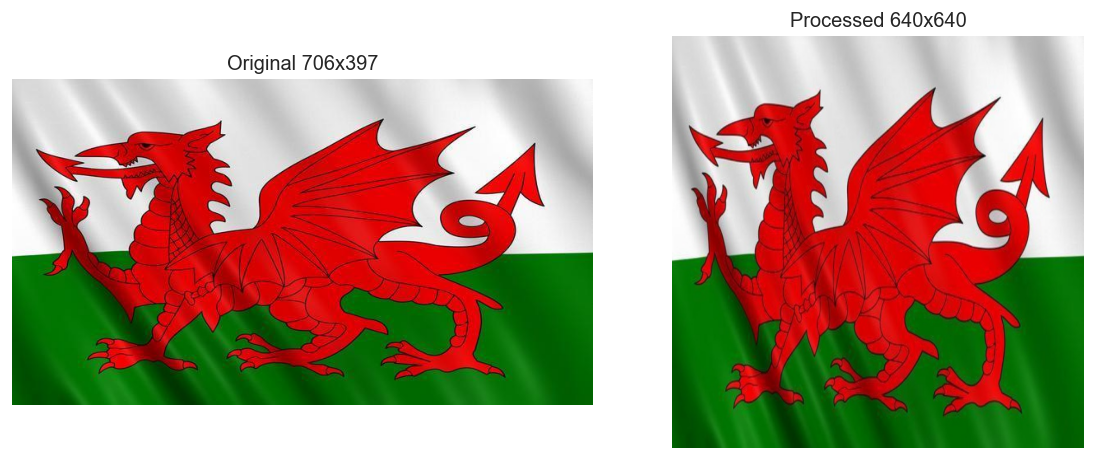

In [15]:
PROCESSED_ROOT = Path('processed_dataset')

# Use most common resolution (or standard YOLOv8 640x640)
RESIZE_W, RESIZE_H = 640, 640

def preprocess_image(src_path: Path, dst_path: Path, size=(640, 640)):
    """Resize + normalize to [0,1] — save as float32 numpy; keep original for training."""
    img = cv2.imread(str(src_path))
    if img is None:
        return False
    img_resized = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
    dst_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(dst_path), img_resized)
    return True

ok_count = fail_count = 0
for split in SPLITS:
    img_dir   = DATASET_ROOT / split / 'images'
    lbl_dir   = DATASET_ROOT / split / 'labels'
    dst_img   = PROCESSED_ROOT / split / 'images'
    dst_lbl   = PROCESSED_ROOT / split / 'labels'
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)
    for img_path in tqdm(get_image_paths(split), desc=f'Processing {split}'):
        dst = dst_img / img_path.name
        if preprocess_image(img_path, dst, (RESIZE_W, RESIZE_H)):
            ok_count += 1
        else:
            fail_count += 1
        lbl_src = lbl_dir / (img_path.stem + '.txt')
        lbl_dst = dst_lbl / (img_path.stem + '.txt')
        if lbl_src.exists():
            shutil.copy(lbl_src, lbl_dst)

# Copy data.yaml
shutil.copy(DATASET_ROOT / 'data.yaml', PROCESSED_ROOT / 'data.yaml')

print(f'Processed OK  : {ok_count}')
print(f'Failed        : {fail_count}')
print(f'Output root   : {PROCESSED_ROOT.resolve()}')

# Visualize sample before/after
sample_img = get_image_paths('train')[0]
before = cv2.cvtColor(cv2.imread(str(sample_img)), cv2.COLOR_BGR2RGB)
after_path = PROCESSED_ROOT / 'train' / 'images' / sample_img.name
after  = cv2.cvtColor(cv2.imread(str(after_path)), cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(before); ax[0].set_title(f'Original {before.shape[1]}x{before.shape[0]}')
ax[1].imshow(after);  ax[1].set_title(f'Processed {after.shape[1]}x{after.shape[0]}')
for a in ax: a.axis('off')
plt.tight_layout()
plt.savefig('outputs/preprocess_sample.png', dpi=150)
plt.show()